In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.patches import Rectangle
import cmocean

from lo_tools import plotting_functions as pfun

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import FancyBboxPatch

In [6]:
years = [2014, 2015, 2016, 2017]
keys = ["obs", "cas7_t1_x11ab", "ssc"]

data_list = []
for yy in years:
    fn = f"./combined_bottle_{yy}_cas7_t1_x11ab_ssc.pkl"
    data_list.append(pd.read_pickle(fn))

# concatenate for each key
data_all = {}
for k in keys:
    data_all[k] = pd.concat([d[k] for d in data_list], ignore_index=True)

print(data_all.keys())
print("obs:", data_all["obs"].shape)
print("cas7_t1_x11ab:", data_all["cas7_t1_x11ab"].shape)
print("ssc:", data_all["ssc"].shape)

dict_keys(['obs', 'cas7_t1_x11ab', 'ssc'])
obs: (20078, 19)
cas7_t1_x11ab: (20078, 16)
ssc: (20078, 14)


In [4]:
data = pd.read_pickle("./combined_bottle_2014_cas7_t1_x11ab_ssc.pkl")

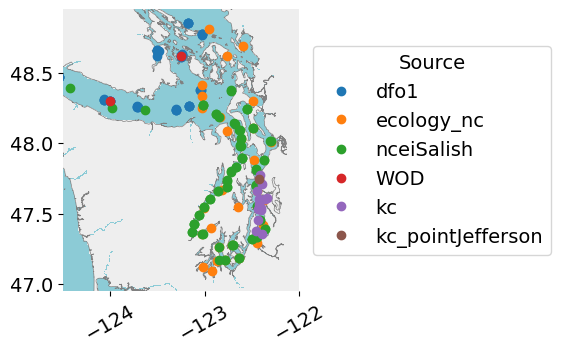

In [21]:
# create map

# Puget Sound only
# lat_low = 46.95
# lat_high = 48.95
# lon_low = -123.3
# lon_high = -122.1

# including Strait of Juan de Fuca 
lat_low = 46.95
lat_high = 48.95
lon_low = -124.5
lon_high = -122

# zoomed in
# lat_low = 47.00
# lat_high = 48.35
# lon_low = -123.2
# lon_high = -122.25

obs= data['obs'].copy()

# One point per station/source
stations = (
    obs[['name', 'lon', 'lat', 'source']]
    .drop_duplicates()
)

ds = xr.open_dataset('../../LO_data/grids/cas7/grid.nc')
z = -ds.h.values
mask_rho = np.transpose(ds.mask_rho.values)
lon = ds.lon_rho.values
lat = ds.lat_rho.values

plon, plat = pfun.get_plon_plat(lon, lat)

zm = z.copy()
zm[np.transpose(mask_rho) == 0] = np.nan
zm[np.transpose(mask_rho) != 0] = -1

# --- colors by source ---
sources = stations['source'].unique()
colors = dict(zip(sources, plt.cm.tab10(range(len(sources)))))

pfun.start_plot(figsize=(6,11))
fig = plt.gcf()
ax = fig.add_subplot(1,1,1)
plt.subplots_adjust(wspace=0, hspace=0.1)

# Map background
ax.add_patch(Rectangle((lon_low, lat_low),
                       lon_high-lon_low,
                       lat_high-lat_low,
                       facecolor='#EEEEEE'))

plt.pcolormesh(plon, plat, zm,
               vmin=-5, vmax=0,
               cmap=cmocean.cm.ice)

pfun.add_coast(ax, color='gray')
ax.axis([lon_low, lon_high, lat_low, lat_high])
pfun.dar(ax)

# --- plot stations by source ---
for src in sources:
    sub = stations[stations['source'] == src]

    ax.plot(sub['lon'], sub['lat'],
            linestyle='none',
            marker='o',
            color=colors[src],
            label=src)

    # # labels
    # for _, row in sub.iterrows():
    #     ax.text(row['lon'], row['lat'] + 0.01,
    #             row['name'],
    #             va='bottom', ha='center',
    #             fontsize=8, fontweight='bold')

ax.legend(title='Source', loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30)

for border in ['top','right','bottom','left']:
    ax.spines[border].set_visible(False)

fig.tight_layout()
plt.show()
#plt.savefig(out_dir / 'cast_locations_by_source.png', bbox_inches='tight')

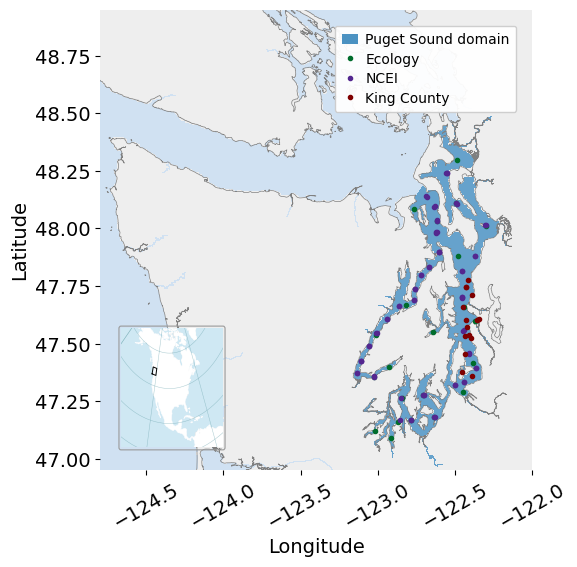

In [ ]:
# include puget sound boundary

# create map

# Puget Sound only
# lat_low = 46.95
# lat_high = 48.95
# lon_low = -123.3
# lon_high = -122.1

# including Strait of Juan de Fuca 
lat_low = 46.95
lat_high = 48.95
lon_low = -124.8
lon_high = -122

# zoomed in
# lat_low = 47.00
# lat_high = 48.35
# lon_low = -123.2
# lon_high = -122.25

obs= data['obs'].copy()

# One point per station/source
stations = (
    obs[['name', 'lon', 'lat', 'source']]
    .drop_duplicates()
)

stations = (
    obs[["name", "lon", "lat", "source"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# replace kc_pointJefferson with kc to avoid duplicate legend entries
stations["source"] = stations["source"].replace({
    "kc_pointJefferson": "kc"
})

stations["source"] = stations["source"].replace({
    "kc": "King County",
    "ecology_nc": "Ecology",
    "nceiSalish": "NCEI",
})

# --- Load LiveOcean grid ---
ds = xr.open_dataset('../../LO_data/grids/cas7/grid.nc')
z = -ds.h.values
mask_rho = np.transpose(ds.mask_rho.values)
lon = ds.lon_rho.values
lat = ds.lat_rho.values

plon, plat = pfun.get_plon_plat(lon, lat)

zm = z.copy()
zm[np.transpose(mask_rho) == 0] = np.nan
zm[np.transpose(mask_rho) != 0] = -1


# --- Load Puget Sound basin mask ---
mask_fn = '../obsmod/basin_masks_from_pugetsoundDObox.nc'
ds_mask = xr.open_dataset(mask_fn)

ps_mask = ds_mask['mask_pugetsound'].values
ps_lon = ds_mask["lon_rho"].values
ps_lat = ds_mask["lat_rho"].values

# Convert mask to 1 / NaN
ps_mask = np.where(ps_mask > 0, 1, np.nan)

# Make plotting corner coordinates from the mask grid, not LO grid
ps_plon, ps_plat = pfun.get_plon_plat(ps_lon, ps_lat)

# --- filter stations to only those in Puget Sound ---
# Flatten the mask grid
mask_lon = ds_mask["lon_rho"].values.ravel()
mask_lat = ds_mask["lat_rho"].values.ravel()
mask_vals = ds_mask['mask_pugetsound'].values.ravel()

# Build nearest-neighbor search tree
tree = cKDTree(np.column_stack((mask_lon, mask_lat)))

# Find nearest mask cell for each station
dist, idx = tree.query(
    np.column_stack((stations["lon"], stations["lat"]))
)

# Keep only stations inside the Puget Sound domain
stations = stations[mask_vals[idx] > 0].copy()

# --- colors by source ---
sources = stations['source'].unique()
# station_colors = dict(zip(sources, plt.cm.Dark2.colors[:len(sources)]))
station_colors = {
    "Ecology": "#006D2C",      # dark green
    "King County": "#7F0000",  # dark red
    "NCEI": "#54278F",         # dark purple
}

pfun.start_plot(figsize=(6,7))
fig = plt.gcf()
ax = fig.add_subplot(1,1,1)
plt.subplots_adjust(wspace=0, hspace=0.1)

# Map background
ax.add_patch(Rectangle((lon_low, lat_low),
                       lon_high-lon_low,
                       lat_high-lat_low,
                       facecolor='#EEEEEE'))

# Water background
plt.pcolormesh(plon, plat, zm,
               vmin=-5, vmax=0,
               cmap=plt.cm.Blues_r)

# Highlight Puget Sound mask
ps_cmap = ListedColormap(['#1F78B4'])
ax.pcolormesh(ps_plon, ps_plat, ps_mask,
              cmap=ps_cmap,
              alpha=0.6,
              zorder=2)

domain_patch = Patch(
    facecolor='#1F78B4',
    edgecolor='none',
    alpha=0.8,
    label='Puget Sound domain'
)

pfun.add_coast(ax, color='gray')
ax.axis([lon_low, lon_high, lat_low, lat_high])
pfun.dar(ax)

# --- plot stations by source ---
for src in sources:
    sub = stations[stations['source'] == src]

    ax.plot(sub['lon'], sub['lat'],
            linestyle='none',
            marker='o',
            markersize=3,
            color=station_colors[src],
            label=src)

    # # labels
    # for _, row in sub.iterrows():
    #     ax.text(row['lon'], row['lat'] + 0.01,
    #             row['name'],
    #             va='bottom', ha='center',
    #             fontsize=8, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
handles.insert(0, domain_patch)

ax.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),   # inside the axes
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="0.8",
    fontsize=10,
    title=None,
    borderpad=0.5,
    labelspacing=0.4,
    handlelength=1.2,
    handletextpad=0.5,
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.xticks(rotation=30)

for border in ['top','right','bottom','left']:
    ax.spines[border].set_visible(False)

fig.tight_layout()

# --------------------
# North America inset map
# --------------------
proj = ccrs.AlbersEqualArea(
    central_longitude=-100,
    central_latitude=45,
    standard_parallels=(20, 60)
)

axins = fig.add_axes(
    [0.22, 0.25, 0.17, 0.17],
    projection=proj
)
axins.set_aspect('auto')
axins.set_extent([-145, -50, 5, 70], crs=ccrs.PlateCarree())


# Background
axins.set_facecolor("#A9D8DE")
axins.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=1)
axins.add_feature(cfeature.COASTLINE, linewidth=0.3, edgecolor="white", zorder=2)
axins.add_feature(
    cfeature.OCEAN,
    facecolor="#CFE8F3",   
    edgecolor="none",
    zorder=0,
)

# Optional faint gridlines
gl = axins.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.35,
    color="#6FA7B0",
    alpha=0.6,
    linestyle="-",
)

# Expand the box by this many degrees
lon_pad = 1.5
lat_pad = 1.0

box_lons = [
    lon_low - lon_pad,
    lon_high + lon_pad,
    lon_high + lon_pad,
    lon_low - lon_pad,
    lon_low - lon_pad,
]

box_lats = [
    lat_low - lat_pad,
    lat_low - lat_pad,
    lat_high + lat_pad,
    lat_high + lat_pad,
    lat_low - lat_pad,
]

axins.plot(
    box_lons,
    box_lats,
    transform=ccrs.PlateCarree(),
    color="black",
    linewidth=0.7,
    zorder=5,
)

# Remove outer frame/ticks
axins.set_xticks([])
axins.set_yticks([])
axins.set_frame_on(False)

# Rounded border around inset
border = FancyBboxPatch(
    (0, 0), 1, 1,
    boxstyle="round,pad=0.02",
    transform=axins.transAxes,
    fill=False,
    edgecolor="0.6",      # light gray like the legend
    linewidth=0.8,
    clip_on=False,
    zorder=10,
)

axins.add_patch(border)

for spine in axins.spines.values():
    spine.set_visible(False)
    
plt.show()
#plt.savefig(out_dir / 'cast_locations_by_source.png', bbox_inches='tight')

In [7]:
# Keep only rows where source is not NaN / None / empty
obs = data_all['obs']

obs_src = obs[
    obs['source'].notna() & 
    (obs['source'].astype(str).str.strip() != '')
]

# Build station table
stn_df = (
    obs_src[['name', 'lat', 'lon', 'source']]
    .drop_duplicates()
)

# Clean station names
stn_df = stn_df[stn_df['name'].notna()]
stn_df = stn_df[stn_df['name'].apply(lambda x: isinstance(x, str))]
stn_df = stn_df[~stn_df['name'].str.fullmatch(r'\d+')]

# Sort
stn_df = stn_df.sort_values('name').reset_index(drop=True)

# Print
for _, row in stn_df.iterrows():
    print(
        f"{row['name']}: "
        f"lat = {row['lat']:.5f}, "
        f"lon = {row['lon']:.5f}, "
        f"source = {row['source']}"
    )

ADM001: lat = 48.03000, lon = -122.61670, source = ecology_nc
ADM002: lat = 48.18750, lon = -122.84170, source = ecology_nc
ADM003: lat = 47.87917, lon = -122.48180, source = ecology_nc
BLL009: lat = 48.68667, lon = -122.59830, source = ecology_nc
BLL040: lat = 48.68397, lon = -122.53820, source = ecology_nc
BUD005: lat = 47.09167, lon = -122.91670, source = ecology_nc
CK200P: lat = 47.71270, lon = -122.38800, source = kc
CMB003: lat = 47.29000, lon = -122.44830, source = ecology_nc
CRR001: lat = 47.27667, lon = -122.70830, source = ecology_nc
CSE001: lat = 47.26500, lon = -122.84330, source = ecology_nc
DNA001: lat = 47.16167, lon = -122.87000, source = ecology_nc
EAP001: lat = 47.41667, lon = -122.38000, source = ecology_nc
ELB015: lat = 47.59667, lon = -122.36830, source = ecology_nc
GOR001: lat = 47.18333, lon = -122.63330, source = ecology_nc
GRG002: lat = 48.80833, lon = -122.95330, source = ecology_nc
HCB003: lat = 47.53833, lon = -123.00830, source = ecology_nc
HCB004: lat = 47

In [5]:
# Filter observations to Ecology source only
obs_ecology = data_all['obs'][data_all['obs']['source'] == 'ecology_nc']

# Create dataframe of unique stations with lat/lon/source
stn_df = (
    obs_ecology[['name', 'lat', 'lon', 'source']]
    .drop_duplicates()
)

# Sort alphabetically
stn_df = stn_df.sort_values('name').reset_index(drop=True)

# Print station coordinates and source
for _, row in stn_df.iterrows():
    print(
        f"{row['name']}: "
        f"lat = {row['lat']:.5f}, "
        f"lon = {row['lon']:.5f} "
    )

ADM001: lat = 48.03000, lon = -122.61670 
ADM002: lat = 48.18750, lon = -122.84170 
ADM003: lat = 47.87917, lon = -122.48180 
BLL009: lat = 48.68667, lon = -122.59830 
BLL040: lat = 48.68397, lon = -122.53820 
BUD005: lat = 47.09167, lon = -122.91670 
CMB003: lat = 47.29000, lon = -122.44830 
CRR001: lat = 47.27667, lon = -122.70830 
CSE001: lat = 47.26500, lon = -122.84330 
DNA001: lat = 47.16167, lon = -122.87000 
EAP001: lat = 47.41667, lon = -122.38000 
ELB015: lat = 47.59667, lon = -122.36830 
GOR001: lat = 47.18333, lon = -122.63330 
GRG002: lat = 48.80833, lon = -122.95330 
HCB003: lat = 47.53833, lon = -123.00830 
HCB004: lat = 47.35667, lon = -123.02330 
HCB007: lat = 47.39833, lon = -122.92830 
HCB010: lat = 47.66700, lon = -122.82000 
NSQ002: lat = 47.16833, lon = -122.78670 
PSB003: lat = 47.66000, lon = -122.44170 
PSS019: lat = 48.01167, lon = -122.30000 
PTH005: lat = 48.08333, lon = -122.76330 
RSR837: lat = 48.61649, lon = -122.76296 
SAR003: lat = 48.10833, lon = -122

In [8]:
# print the lat lon of chosen stations

station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

# Filter observations to Ecology source only
obs_ecology = data_all['obs'][
    data_all['obs']['source'] == 'ecology_nc'
]

# Keep only selected stations
obs_ecology = obs_ecology[
    obs_ecology['name'].isin(station_names)
]

# Create dataframe of unique stations with lat/lon/source
stn_df = (
    obs_ecology[['name', 'lat', 'lon', 'source']]
    .drop_duplicates()
)

# Print station coordinates and source
for _, row in stn_df.iterrows():
    print(
        f"{row['name']}: "
        f"lat = {row['lat']:.5f}, "
        f"lon = {row['lon']:.5f}, " )

SAR003: lat = 48.10833, lon = -122.49000, 
CMB003: lat = 47.29000, lon = -122.44830, 
CSE001: lat = 47.26500, lon = -122.84330, 
GOR001: lat = 47.18333, lon = -122.63330, 
ADM003: lat = 47.87917, lon = -122.48180, 
EAP001: lat = 47.41667, lon = -122.38000, 
HCB003: lat = 47.53833, lon = -123.00830, 
HCB004: lat = 47.35667, lon = -123.02330, 
PSB003: lat = 47.66000, lon = -122.44170, 
SIN001: lat = 47.55000, lon = -122.64170, 
PSS019: lat = 48.01167, lon = -122.30000, 
SKG003: lat = 48.29667, lon = -122.48830, 


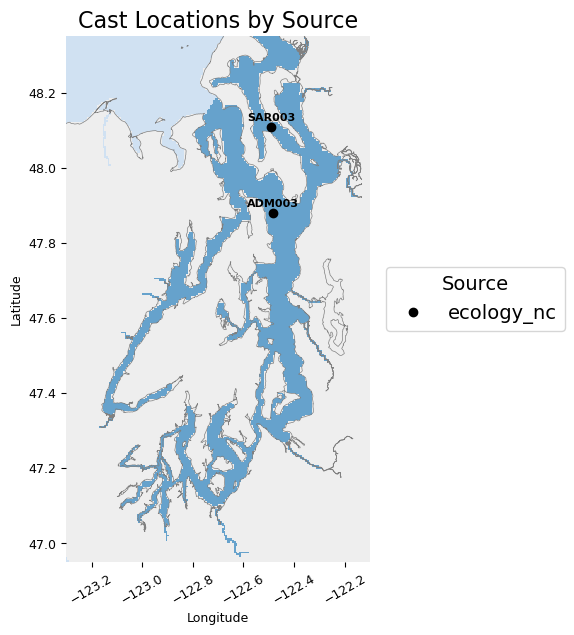

In [17]:
# plot specific stations on map
# station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]
# station_names = ["SAR003", "HCB003", "ADM003", "CSE001"]
station_names = ["SAR003", "ADM003"]

# Filter stn_df to selected stations only
stn_df = stn_df[stn_df['name'].isin(station_names)]

# --- Load Puget Sound basin mask ---
mask_fn = '../obsmod/basin_masks_from_pugetsoundDObox.nc'
ds_mask = xr.open_dataset(mask_fn)

ps_mask = ds_mask['mask_pugetsound'].values
ps_lon = ds_mask["lon_rho"].values
ps_lat = ds_mask["lat_rho"].values

# Convert mask to 1 / NaN
ps_mask = np.where(ps_mask > 0, 1, np.nan)

# Make plotting corner coordinates from the mask grid, not LO grid
ps_plon, ps_plat = pfun.get_plon_plat(ps_lon, ps_lat)

# --- filter stations to only those in Puget Sound ---
# Flatten the mask grid
mask_lon = ds_mask["lon_rho"].values.ravel()
mask_lat = ds_mask["lat_rho"].values.ravel()
mask_vals = ds_mask['mask_pugetsound'].values.ravel()

# Build nearest-neighbor search tree
tree = cKDTree(np.column_stack((mask_lon, mask_lat)))


# create map

# Puget Sound only
lat_low = 46.95
lat_high = 48.35
lon_low = -123.3
lon_high = -122.1

# zoomed in
# lat_low = 47.00
# lat_high = 48.35
# lon_low = -123.2
# lon_high = -122.25

ds = xr.open_dataset('../../LO_data/grids/cas7/grid.nc')
z = -ds.h.values
mask_rho = np.transpose(ds.mask_rho.values)
lon = ds.lon_rho.values
lat = ds.lat_rho.values

plon, plat = pfun.get_plon_plat(lon, lat)

zm = z.copy()
zm[np.transpose(mask_rho) == 0] = np.nan
zm[np.transpose(mask_rho) != 0] = -1

# --- colors by source ---
sources = stn_df['source'].unique()
colors = dict(zip(sources, plt.cm.tab10(range(len(sources)))))

pfun.start_plot(figsize=(6,11))
fig = plt.gcf()
ax = fig.add_subplot(1,1,1)
plt.subplots_adjust(wspace=0, hspace=0.1)

# Map background
ax.add_patch(Rectangle((lon_low, lat_low),
                       lon_high-lon_low,
                       lat_high-lat_low,
                       facecolor='#EEEEEE'))

# Water background
plt.pcolormesh(plon, plat, zm,
               vmin=-5, vmax=0,
               cmap=plt.cm.Blues_r)

# Highlight Puget Sound mask
ps_cmap = ListedColormap(['#1F78B4'])
ax.pcolormesh(ps_plon, ps_plat, ps_mask,
              cmap=ps_cmap,
              alpha=0.6,
              zorder=2)

pfun.add_coast(ax, color='gray')
ax.axis([lon_low, lon_high, lat_low, lat_high])
pfun.dar(ax)

# --- plot stations by source ---
for src in sources:
    sub = stn_df[stn_df['source'] == src]

    ax.plot(sub['lon'], sub['lat'],
            linestyle='none',
            marker='o',
            # color='colors[src]',
            color = 'k',
            label=src)

    # labels
    for _, row in sub.iterrows():
        ax.text(row['lon'], row['lat'] + 0.01,
                row['name'],
                va='bottom', ha='center',
                fontsize=8, fontweight='bold')

ax.legend(title='Source', loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize= 9)
ax.tick_params(axis='both', which='major', labelsize=9)
plt.xticks(rotation=30)

for border in ['top','right','bottom','left']:
    ax.spines[border].set_visible(False)

plt.title('Cast Locations by Source', fontsize=16)
fig.tight_layout()
plt.show()
#plt.savefig(out_dir / 'cast_locations_by_source.png', bbox_inches='tight')

In [ ]:
# plot specific stations on map
# station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]
# station_names = ["SAR003", "HCB003", "ADM003", "CSE001"]
station_names = ["SAR003", "ADM003"]

# Filter stn_df to selected stations only
stn_df = stn_df[stn_df['name'].isin(station_names)]

# --- Load basin masks ---
mask_fn = '../obsmod/basin_masks_from_pugetsoundDObox.nc'
ds_mask = xr.open_dataset(mask_fn)

ps_mask = ds_mask['mask_pugetsound'].values
ps_lon = ds_mask["lon_rho"].values
ps_lat = ds_mask["lat_rho"].values

wb_mask = ds_mask['mask_whidbeybasin'].values

# Convert mask to 1 / NaN
ps_mask = np.where(ps_mask > 0, 1, np.nan)

# Make plotting corner coordinates from the mask grid, not LO grid
ps_plon, ps_plat = pfun.get_plon_plat(ps_lon, ps_lat)

# --- filter stations to only those in Puget Sound ---
# Flatten the mask grid
mask_lon = ds_mask["lon_rho"].values.ravel()
mask_lat = ds_mask["lat_rho"].values.ravel()
mask_vals = ds_mask['mask_pugetsound'].values.ravel()

# Build nearest-neighbor search tree
tree = cKDTree(np.column_stack((mask_lon, mask_lat)))

# create map

# Puget Sound only
lat_low = 46.95
lat_high = 48.35
lon_low = -123.3
lon_high = -122.1

# zoomed in
# lat_low = 47.00
# lat_high = 48.35
# lon_low = -123.2
# lon_high = -122.25

ds = xr.open_dataset('../../LO_data/grids/cas7/grid.nc')
z = -ds.h.values
mask_rho = np.transpose(ds.mask_rho.values)
lon = ds.lon_rho.values
lat = ds.lat_rho.values

plon, plat = pfun.get_plon_plat(lon, lat)

zm = z.copy()
zm[np.transpose(mask_rho) == 0] = np.nan
zm[np.transpose(mask_rho) != 0] = -1

# --- colors by source ---
sources = stn_df['source'].unique()
colors = dict(zip(sources, plt.cm.tab10(range(len(sources)))))

pfun.start_plot(figsize=(6,11))
fig = plt.gcf()
ax = fig.add_subplot(1,1,1)
plt.subplots_adjust(wspace=0, hspace=0.1)

# Map background
ax.add_patch(Rectangle((lon_low, lat_low),
                       lon_high-lon_low,
                       lat_high-lat_low,
                       facecolor='#EEEEEE'))

# Water background
plt.pcolormesh(plon, plat, zm,
               vmin=-5, vmax=0,
               cmap=plt.cm.Blues_r)

# Highlight basin masks
wb_cmap = ListedColormap(['#1F78B4'])
ax.pcolormesh(ps_plon, ps_plat, wb_mask,
              cmap=wb_cmap,
              alpha=0.6,
              zorder=2)

pfun.add_coast(ax, color='gray')
ax.axis([lon_low, lon_high, lat_low, lat_high])
pfun.dar(ax)

# --- plot stations by source ---
for src in sources:
    sub = stn_df[stn_df['source'] == src]

    ax.plot(sub['lon'], sub['lat'],
            linestyle='none',
            marker='o',
            # color='colors[src]',
            color = 'k',
            label=src)

    # labels
    for _, row in sub.iterrows():
        ax.text(row['lon'], row['lat'] + 0.01,
                row['name'],
                va='bottom', ha='center',
                fontsize=8, fontweight='bold')

ax.legend(title='Source', loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize= 9)
ax.tick_params(axis='both', which='major', labelsize=9)
plt.xticks(rotation=30)

for border in ['top','right','bottom','left']:
    ax.spines[border].set_visible(False)

plt.title('Cast Locations by Source', fontsize=16)
fig.tight_layout()
plt.show()
#plt.savefig(out_dir / 'cast_locations_by_source.png', bbox_inches='tight')